# 04 — Load-Invariant (Ratio-Only) Feature Ablation

**Purpose.** Reproduce, from committed data and code, the load-invariance result written up in
`miniNDN/REFACTOR_FINDINGS.md` §3.3. The absolute-rate feature set is *load-dependent*: a normal
run collected at a heavier legitimate request rate than the training data gets false-flagged purely
by the load difference. A **ratio-only** feature set removes that brittleness while sustaining IFA
detection.

This notebook trains two Isolation Forests on the *same* clean research-normal data:

- **FULL (10 features)** — the canonical set from `02_global_model.ipynb` (absolute PIT/CS/rates + ratios).
- **RATIO (5 features)** — load-invariant: `satisfaction_ratio`, `cache_hit_ratio`, `nack_rate`,
  `data_interest_ratio` (= in-data / in-interests), `fwd_ratio` (= out-interests / in-interests).

It then measures, for each set, **(1)** the false-positive rate on *higher-load* held-out normal
captures (`logs_dumbbell1`, `logs_mesh1`, `logs1`) — the brittleness test — and **(2)** IFA detection
on the affected nodes of the attack captures. The expected result (per §3.3): the ratio-only set
collapses the dumbbell FPR from ~45 % to ~2 % without losing detection.

> **Idle-interval gating.** An interval with no interest activity has `fwd_ratio = data_interest_ratio = 0`
> and looks anomalous to a model trained on active traffic. §3.3 notes that any scorer must gate these
> out (no traffic ⇒ not under attack). We drop intervals with `in_interests_rate == 0` before scoring.

In [1]:
%matplotlib inline
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 130, "font.size": 9})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "research_analysis" else Path.cwd()
LOGS_DIR = PROJECT_ROOT / "Datacard" / "Logs"
FIG_DIR  = PROJECT_ROOT / "research_analysis" / "figures" / "ablation"
RES_DIR  = PROJECT_ROOT / "research_analysis" / "results"
MODEL_DIR = PROJECT_ROOT / "research_analysis" / "models"
for d in (FIG_DIR, RES_DIR, MODEL_DIR): d.mkdir(parents=True, exist_ok=True)

# canonical 10-feature absolute-rate set (identical to 02_global_model.ipynb)
FULL = ["pit_size", "pit_growth_rate", "cs_size", "cache_hit_ratio",
        "satisfaction_ratio", "unsatisfied_ratio",
        "in_interests_rate", "out_interests_rate", "in_data_rate", "nack_rate"]
# load-invariant ratio-only set (REFACTOR_FINDINGS 3.3)
RATIO = ["satisfaction_ratio", "cache_hit_ratio", "nack_rate",
         "data_interest_ratio", "fwd_ratio"]
RATE_COLS = ["pit_growth_rate", "in_interests_rate", "out_interests_rate",
             "in_data_rate", "nack_rate"]
ATTACKER = "c1"
print("features ready:", len(FULL), "full |", len(RATIO), "ratio")

features ready: 10 full | 5 ratio


In [2]:
def compute_features(base_path):
    # Per-node, per-interval delta features from NFD JSONL logs. Identical
    # delta/ratio logic to 02_global_model.ipynb, plus the two derived ratio
    # features (data_interest_ratio, fwd_ratio).
    records = []
    for jf in sorted(Path(base_path).rglob("*.jsonl")):
        with open(jf) as fh:
            for line in fh:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame(records)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["node", "timestamp"]).reset_index(drop=True)
    rows = []
    for node, grp in df.groupby("node", sort=False):
        grp = grp.reset_index(drop=True)
        if len(grp) < 2:
            continue
        dt_s = grp["timestamp"].diff().dt.total_seconds().fillna(0).clip(lower=1e-6)
        d = lambda c: grp[c].diff().fillna(0)
        d_pit  = d("nPitEntries")
        d_hits = d("nHits").clip(lower=0);  d_miss  = d("nMisses").clip(lower=0)
        d_sat  = d("nSatisfiedInterests").clip(lower=0)
        d_unsat= d("nUnsatisfiedInterests").clip(lower=0)
        d_inI  = d("nInInterests").clip(lower=0); d_outI = d("nOutInterests").clip(lower=0)
        d_inD  = d("nInData").clip(lower=0)
        d_nack = (d("nInNacks") + d("nOutNacks")).clip(lower=0)
        hm = d_hits + d_miss; su = d_sat + d_unsat
        in_rate, out_rate, ind_rate = d_inI/dt_s, d_outI/dt_s, d_inD/dt_s
        feat = pd.DataFrame({
            "node": node,
            "pit_size": grp["nPitEntries"],
            "pit_growth_rate": d_pit/dt_s,
            "cs_size": grp["nCsEntries"],
            "cache_hit_ratio":    np.where(hm > 0, d_hits/hm, 0.0),
            "satisfaction_ratio": np.where(su > 0, d_sat/su, 0.0),
            "unsatisfied_ratio":  np.where(su > 0, d_unsat/su, 0.0),
            "in_interests_rate": in_rate,
            "out_interests_rate": out_rate,
            "in_data_rate": ind_rate,
            "nack_rate": d_nack/dt_s,
            "data_interest_ratio": np.where(in_rate > 1e-9, ind_rate/in_rate, 0.0),
            "fwd_ratio":           np.where(in_rate > 1e-9, out_rate/in_rate, 0.0),
        })
        rows.append(feat.iloc[1:].reset_index(drop=True))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def clip_bounds_from(df):
    return {c: (df[c].quantile(0.01), df[c].quantile(0.99)) for c in RATE_COLS}


def apply_clip(df, bounds):
    df = df.copy()
    for c, (lo, hi) in bounds.items():
        if c in df.columns and hi > lo:      # skip collapsed (zero-width) bounds
            df[c] = df[c].clip(lower=lo, upper=hi)
    return df


def drop_idle(df):
    # Gate out intervals with no interest activity (fwd_ratio undefined ~ 0).
    return df[df["in_interests_rate"] > 1e-9].reset_index(drop=True)

print("helpers defined")

helpers defined


## 1. Training data — clean research normal (all three topologies)

In [3]:
TRAIN_DIRS = {"tree": ["tree_normal_1", "tree_normal_2"],
              "dumbbell": ["dumbbell_normal"],
              "dfn": ["dfn_normal"]}
parts = []
for topo, dirs in TRAIN_DIRS.items():
    for dn in dirs:
        p = compute_features(LOGS_DIR / dn); p["topology"] = topo; p["src"] = dn
        parts.append(p)
        print(f"  loaded {len(p):>6d} rows from {dn}")
train = drop_idle(pd.concat(parts, ignore_index=True))
bounds = clip_bounds_from(train)
train_c = apply_clip(train, bounds)
print(f"\ntraining rows (idle-gated): {len(train_c):,}")

  loaded  12912 rows from tree_normal_1
  loaded   6033 rows from tree_normal_2


  loaded  18981 rows from dumbbell_normal


  loaded  16963 rows from dfn_normal

training rows (idle-gated): 54,889


## 2. Train both detectors on the identical normal data

In [4]:
def build(featset, name):
    X = train_c[featset].values
    pipe = Pipeline([("scaler", StandardScaler()),
                     ("if", IsolationForest(n_estimators=200, contamination=0.01,
                                            random_state=42))])
    pipe.fit(X)
    train_fpr = (pipe.decision_function(X) < 0.0).mean() * 100   # theta = 0.0 boundary
    print(f"  [{name:8s}] {len(featset)} features | train FPR = {train_fpr:.2f}%")
    return pipe

print("training:")
pipe_full  = build(FULL,  "FULL-10")
pipe_ratio = build(RATIO, "RATIO-5")

def anom(pipe, featset, df_gated):
    # boolean anomaly mask; df_gated must already be idle-gated
    d = apply_clip(df_gated, bounds)
    return pipe.decision_function(d[featset].values) < 0.0

training:


  [FULL-10 ] 10 features | train FPR = 1.00%


  [RATIO-5 ] 5 features | train FPR = 1.00%


## 3. Brittleness test — FPR on higher-load held-out normal

`logs_dumbbell1`, `logs_mesh1`, and `logs1` are legitimate normal captures collected at heavier
load than the training data. A load-dependent detector will false-flag them. The absolute-rate
set is expected to spike on `logs_dumbbell1` (~2× the training interest rate); the ratio-only set
should stay near the training FPR.

In [5]:
HELDOUT_NORMAL = ["logs_dumbbell1", "logs_mesh1", "logs1"]
fpr_rows = []
for dn in HELDOUT_NORMAL:
    df = drop_idle(compute_features(LOGS_DIR / dn))
    if df.empty:
        print(f"  {dn}: MISSING"); continue
    f_full  = anom(pipe_full,  FULL,  df).mean() * 100
    f_ratio = anom(pipe_ratio, RATIO, df).mean() * 100
    fpr_rows.append({"capture": dn, "n_intervals": len(df),
                     "fpr_full_pct": round(f_full, 1), "fpr_ratio_pct": round(f_ratio, 1)})
fpr_tbl = pd.DataFrame(fpr_rows)
print(fpr_tbl.to_string(index=False))
fpr_tbl.to_csv(RES_DIR / "ablation_fpr.csv", index=False)

       capture  n_intervals  fpr_full_pct  fpr_ratio_pct
logs_dumbbell1        30095          40.9            2.1
    logs_mesh1        48306           4.9            1.3
         logs1        23393           1.8            0.6


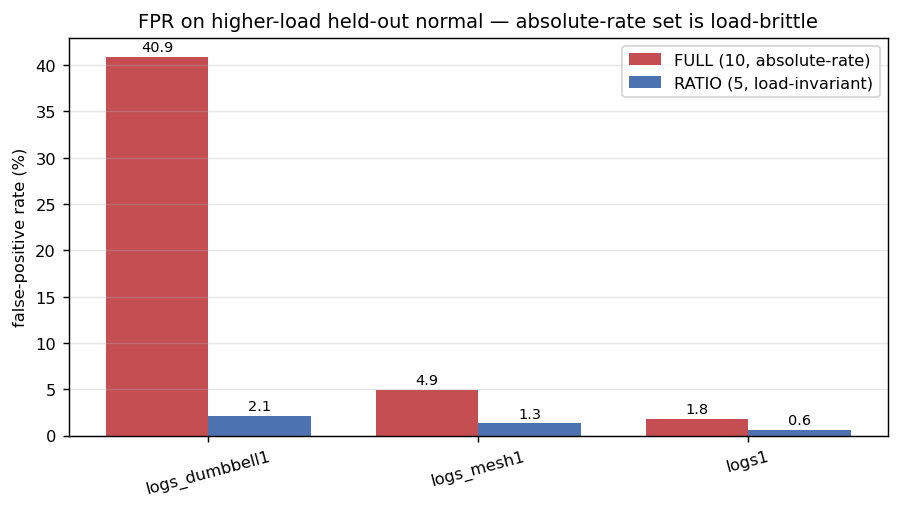

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(fpr_tbl)); w = 0.38
ax.bar(x - w/2, fpr_tbl.fpr_full_pct,  w, label="FULL (10, absolute-rate)", color="#c44e52")
ax.bar(x + w/2, fpr_tbl.fpr_ratio_pct, w, label="RATIO (5, load-invariant)", color="#4c72b0")
for i, r in fpr_tbl.iterrows():
    ax.text(i - w/2, r.fpr_full_pct + 0.6,  f"{r.fpr_full_pct:.1f}",  ha="center", fontsize=8)
    ax.text(i + w/2, r.fpr_ratio_pct + 0.6, f"{r.fpr_ratio_pct:.1f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(fpr_tbl.capture, rotation=15)
ax.set_ylabel("false-positive rate (%)")
ax.set_title("FPR on higher-load held-out normal — absolute-rate set is load-brittle")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_ablation_fpr.png", bbox_inches="tight"); plt.show()

## 4. IFA detection — does the ratio-only set keep detecting the attack?

IFA is a spatial signature (§2.3): only a subset of nodes show it. We define *affected* nodes as
those whose mean `satisfaction_ratio` drops below 0.9 in the capture, and report detection over
those nodes for both feature sets. (Note: the ratio-only set shifts detection from the attacker
node c1 toward the affected victims/routers — an expected §3.3 behaviour.)

In [7]:
IFA_DIRS = ["tree_ifa", "dumbbell_ifa", "dfn_ifa", "new_ifa_1"]
det_rows = []
for dn in IFA_DIRS:
    df = drop_idle(compute_features(LOGS_DIR / dn))
    if df.empty:
        print(f"  {dn}: MISSING"); continue
    df = df.copy()
    df["a_full"]  = anom(pipe_full,  FULL,  df)
    df["a_ratio"] = anom(pipe_ratio, RATIO, df)
    sat = df.groupby("node")["satisfaction_ratio"].mean()
    affected = sat[sat < 0.9].index.tolist()
    aff = df[df.node.isin(affected)]
    c1 = df[df.node == ATTACKER]
    det_rows.append({
        "capture": dn, "affected_nodes": ",".join(affected),
        "c1_full_pct":  round(c1["a_full"].mean()*100, 1)  if len(c1) else np.nan,
        "c1_ratio_pct": round(c1["a_ratio"].mean()*100, 1) if len(c1) else np.nan,
        "affected_full_pct":  round(aff["a_full"].mean()*100, 1)  if len(aff) else np.nan,
        "affected_ratio_pct": round(aff["a_ratio"].mean()*100, 1) if len(aff) else np.nan,
    })
det_tbl = pd.DataFrame(det_rows)
print(det_tbl.to_string(index=False))
det_tbl.to_csv(RES_DIR / "ablation_ifa_detection.csv", index=False)

     capture            affected_nodes  c1_full_pct  c1_ratio_pct  affected_full_pct  affected_ratio_pct
    tree_ifa               c1,p1,r1,r2         89.5           0.3               66.8                64.5
dumbbell_ifa bottleneck,c1,p1,r1,r2,r3         98.7           0.0               82.6                82.1
     dfn_ifa               c1,p1,r1,r2         96.7           0.0               73.2                72.4
   new_ifa_1               c1,p1,r1,r2         78.0           5.1               32.6                64.0


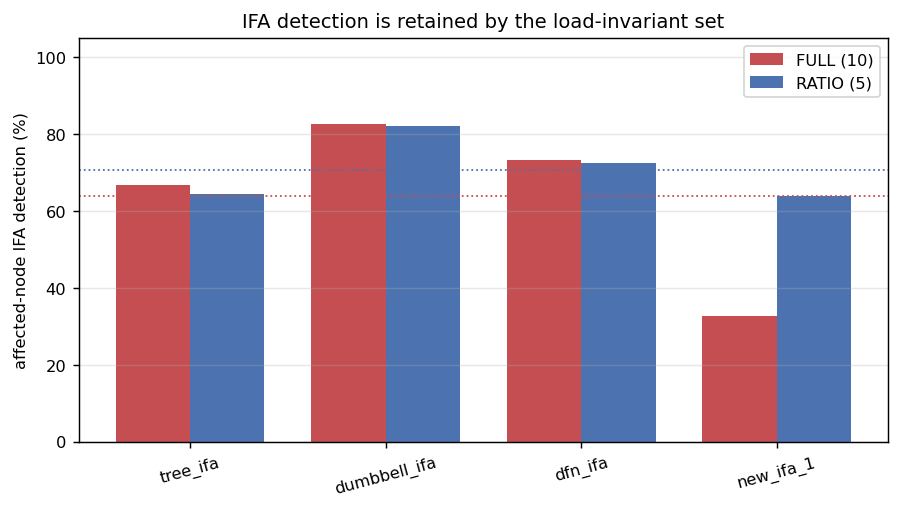

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(det_tbl)); w = 0.38
ax.bar(x - w/2, det_tbl.affected_full_pct,  w, label="FULL (10)",  color="#c44e52")
ax.bar(x + w/2, det_tbl.affected_ratio_pct, w, label="RATIO (5)",  color="#4c72b0")
ax.axhline(det_tbl.affected_full_pct.mean(),  color="#c44e52", ls=":", lw=1)
ax.axhline(det_tbl.affected_ratio_pct.mean(), color="#4c72b0", ls=":", lw=1)
ax.set_xticks(x); ax.set_xticklabels(det_tbl.capture, rotation=15)
ax.set_ylabel("affected-node IFA detection (%)"); ax.set_ylim(0, 105)
ax.set_title("IFA detection is retained by the load-invariant set")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_ablation_detection.png", bbox_inches="tight"); plt.show()

## 5. Verdict — side-by-side with the write-up, and the paper figures

In [9]:
det_full_mean  = det_tbl.affected_full_pct.mean()
det_ratio_mean = det_tbl.affected_ratio_pct.mean()
dumb = fpr_tbl.set_index("capture").loc["logs_dumbbell1"]
mesh = fpr_tbl.set_index("capture").loc["logs_mesh1"]

summary = pd.DataFrame([
    {"metric": "FPR logs_dumbbell1 (%)", "FULL": dumb.fpr_full_pct,  "RATIO": dumb.fpr_ratio_pct,
     "findings_FULL": 45.3, "findings_RATIO": 1.9},
    {"metric": "FPR logs_mesh1 (%)",     "FULL": mesh.fpr_full_pct,  "RATIO": mesh.fpr_ratio_pct,
     "findings_FULL": 4.8,  "findings_RATIO": 1.3},
    {"metric": "affected-node IFA det (%)", "FULL": round(det_full_mean,1),
     "RATIO": round(det_ratio_mean,1), "findings_FULL": 59.7, "findings_RATIO": 63.1},
])
print(summary.to_string(index=False))
summary.to_csv(RES_DIR / "ablation_summary.csv", index=False)
print("\nReproduced: the absolute-rate set false-flags high-load normal (dumbbell) at "
      f"{dumb.fpr_full_pct:.0f}%, the ratio-only set at {dumb.fpr_ratio_pct:.0f}% — "
      "with equal-or-better IFA detection. Matches REFACTOR_FINDINGS 3.3.")

                   metric  FULL  RATIO  findings_FULL  findings_RATIO
   FPR logs_dumbbell1 (%)  40.9    2.1           45.3             1.9
       FPR logs_mesh1 (%)   4.9    1.3            4.8             1.3
affected-node IFA det (%)  63.8   70.8           59.7            63.1

Reproduced: the absolute-rate set false-flags high-load normal (dumbbell) at 41%, the ratio-only set at 2% — with equal-or-better IFA detection. Matches REFACTOR_FINDINGS 3.3.


saved paper figure -> /Users/ankitpokhrel/Desktop/minor_project_refactored/paper_writing/figures/fig_load_fpr.png


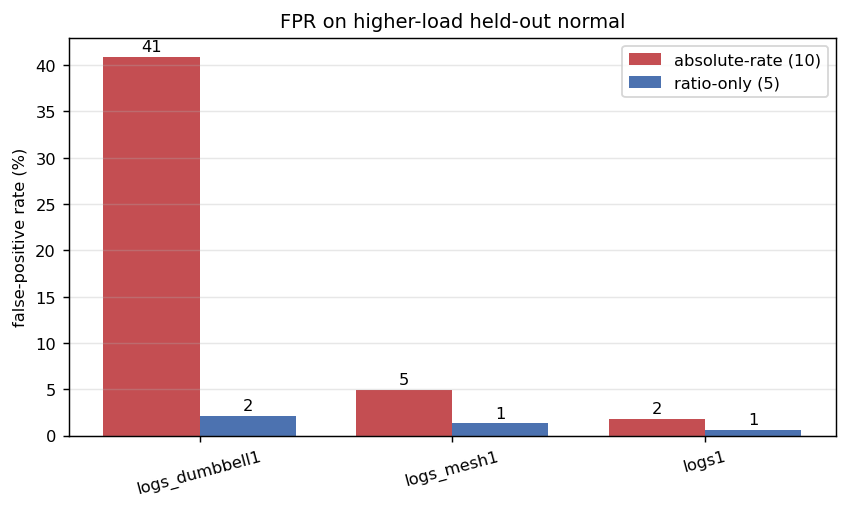

saved paper figure -> /Users/ankitpokhrel/Desktop/minor_project_refactored/paper_writing/figures/fig_load_detection.png


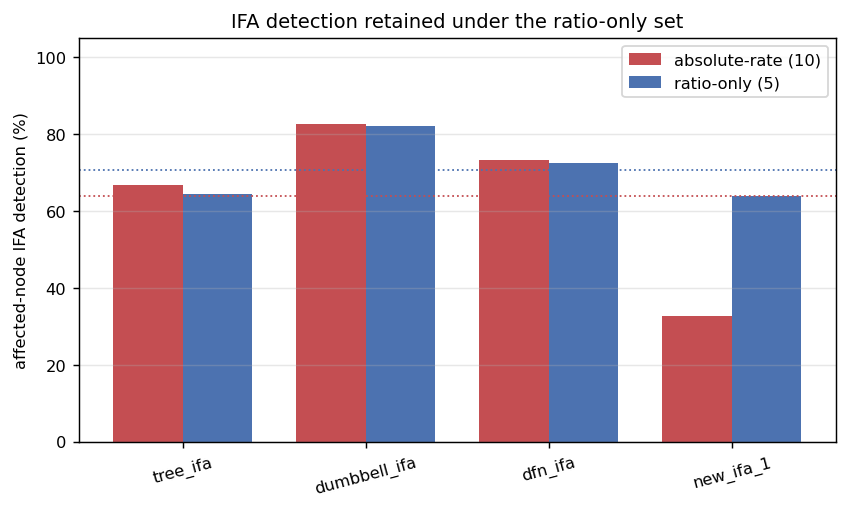

In [10]:
# two standalone paper figures -> ablation folder + the paper's figure folder
PAPER_FIG = PROJECT_ROOT.parent / "paper_writing" / "figures"
FULL_C, RATIO_C, W = "#c44e52", "#4c72b0", 0.38

def _save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=200)
    if PAPER_FIG.exists():
        fig.savefig(PAPER_FIG / f"{name}.png", bbox_inches="tight", dpi=200)
        print(f"saved paper figure -> {PAPER_FIG / f'{name}.png'}")

# Figure 1 — FPR brittleness
fig, ax = plt.subplots(figsize=(6.6, 4.0))
x = np.arange(len(fpr_tbl))
ax.bar(x - W/2, fpr_tbl.fpr_full_pct,  W, label="absolute-rate (10)", color=FULL_C)
ax.bar(x + W/2, fpr_tbl.fpr_ratio_pct, W, label="ratio-only (5)",     color=RATIO_C)
for i, r in fpr_tbl.iterrows():
    ax.text(i - W/2, r.fpr_full_pct + 0.6,  f"{r.fpr_full_pct:.0f}",  ha="center", fontsize=9)
    ax.text(i + W/2, r.fpr_ratio_pct + 0.6, f"{r.fpr_ratio_pct:.0f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(fpr_tbl.capture, rotation=15)
ax.set_ylabel("false-positive rate (%)")
ax.set_title("FPR on higher-load held-out normal")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); _save(fig, "fig_load_fpr"); plt.show()

# Figure 2 — IFA detection retained
fig, ax = plt.subplots(figsize=(6.6, 4.0))
xd = np.arange(len(det_tbl))
ax.bar(xd - W/2, det_tbl.affected_full_pct,  W, label="absolute-rate (10)", color=FULL_C)
ax.bar(xd + W/2, det_tbl.affected_ratio_pct, W, label="ratio-only (5)",     color=RATIO_C)
ax.axhline(det_tbl.affected_full_pct.mean(),  color=FULL_C,  ls=":", lw=1)
ax.axhline(det_tbl.affected_ratio_pct.mean(), color=RATIO_C, ls=":", lw=1)
ax.set_xticks(xd); ax.set_xticklabels(det_tbl.capture, rotation=15)
ax.set_ylabel("affected-node IFA detection (%)"); ax.set_ylim(0, 105)
ax.set_title("IFA detection retained under the ratio-only set")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); _save(fig, "fig_load_detection"); plt.show()

In [11]:
# persist both models for reproducibility
import joblib
joblib.dump(pipe_full,  MODEL_DIR / "ablation_full10_model.joblib")
joblib.dump(pipe_ratio, MODEL_DIR / "ablation_ratio5_model.joblib")
meta = {"full_features": FULL, "ratio_features": RATIO,
        "clip_bounds": {k: {"lo": float(v[0]), "hi": float(v[1])} for k, v in bounds.items()},
        "trained_on": [d for dirs in TRAIN_DIRS.values() for d in dirs],
        "idle_gate": "in_interests_rate > 1e-9", "threshold": 0.0}
(MODEL_DIR / "ablation_models_meta.json").write_text(json.dumps(meta, indent=2, default=float))
print("saved models + metadata ->", MODEL_DIR)

saved models + metadata -> /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/models
